# Build Dictionary
Maps clustered sound units to English words and decodes Rocky's sentences.
See `docs/build_dictionary.md` for theory.

## Imports

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import Counter

print('ready')

ready


## Load

In [11]:
labels      = np.load('../data/cluster_labels.npy')
onset_times = np.load('../data/onset_times.npy')

with open('../data/dictionary.json', 'r') as f:
    dictionary = json.load(f)

cluster_map    = dictionary['cluster_map']       # cluster id → sound name
sentences      = dictionary['sentences']          # sentence name → sound list
english_meaning = dictionary['english_meaning']  # sentence name → english

print(f'units detected  : {len(labels)}')
print(f'cluster map     : {len(cluster_map)} clusters')
print(f'known sentences : {len(sentences)}')
print()
print('cluster map loaded:')
for k, sound in cluster_map.items():
    print(f'  cluster {k:>2} → {sound}')

units detected  : 272
cluster map     : 11 clusters
known sentences : 50

cluster map loaded:
  cluster  0 → hum_high
  cluster  1 → chirp_up
  cluster  2 → chord_simple
  cluster  3 → hum_low
  cluster  4 → click_high
  cluster  5 → chord_rich
  cluster  6 → chirp_down
  cluster  7 → hum_mid
  cluster  8 → click_low
  cluster  9 → click_mid
  cluster 10 → chord_alien


## Defining the sound to English word mapping

In [12]:
# sound name → English word
# designed so sequences of these words form readable sentences
SOUND_TO_WORD = {
    'click_low'    : 'I',
    'click_mid'    : 'here',
    'click_high'   : 'warning',
    'hum_low'      : 'what',
    'hum_mid'      : 'am',
    'hum_high'     : 'safe',
    'chirp_up'     : 'question',
    'chirp_down'   : 'danger',
    'chord_simple' : 'understand',
    'chord_rich'   : 'need',
    'chord_alien'  : 'critical',
}

print('sound → word mapping:')
for sound, word in SOUND_TO_WORD.items():
    print(f'  {sound:20} → {word}')

sound → word mapping:
  click_low            → I
  click_mid            → here
  click_high           → warning
  hum_low              → what
  hum_mid              → am
  hum_high             → safe
  chirp_up             → question
  chirp_down           → danger
  chord_simple         → understand
  chord_rich           → need
  chord_alien          → critical


## Verifying by decoding known sentences using the mapping

In [13]:
print('decoding known sentences:\n')
for sentence_name, sound_list in sentences.items():
    words    = [SOUND_TO_WORD.get(s, '?') for s in sound_list]
    meaning  = english_meaning.get(sentence_name, 'unknown')
    print(f'  sentence      : {sentence_name}')
    print(f'  sounds        : {" → ".join(sound_list)}')
    print(f'  words         : {" → ".join(words)}')
    print(f'  known meaning : {meaning}')
    print()

decoding known sentences:

  sentence      : greeting
  sounds        : click_high → click_high → hum_mid → chirp_up → click_mid
  words         : warning → warning → am → question → here
  known meaning : Hello / I am here

  sentence      : question
  sounds        : hum_low → click_mid → click_low → chirp_up → chirp_up
  words         : what → here → I → question → question
  known meaning : What is this?

  sentence      : danger
  sounds        : chirp_down → chirp_down → chord_alien → click_high → click_high → click_high
  words         : danger → danger → critical → warning → warning → warning
  known meaning : Warning! Danger!

  sentence      : i_understand
  sounds        : chord_simple → hum_mid → click_low → hum_high → chord_rich
  words         : understand → am → I → safe → need
  known meaning : I understand

  sentence      : help_needed
  sounds        : chirp_up → chord_alien → hum_low → chirp_down → click_high → chord_rich
  words         : question → critical → what

## Decoding the detected audio using cluster labels

This is the real test : take the cluster sequence the detector found and convert it to words.

In [14]:
def decode_sequence(cluster_labels, cluster_map, sound_to_word):
    """
    cluster ID → sound name → english word
    returns list of (cluster_id, sound_name, word, onset_time)
    """
    results = []
    for i, label in enumerate(cluster_labels):
        sound_name = cluster_map.get(str(label), 'unknown')
        word       = sound_to_word.get(sound_name, '?')
        onset_t    = onset_times[i] if i < len(onset_times) else 0
        results.append((int(label), sound_name, word, round(float(onset_t), 3)))
    return results

decoded = decode_sequence(labels, cluster_map, SOUND_TO_WORD)

print(f'full decoded sequence ({len(decoded)} units):\n')
print(f'{"#":4} {"time":8} {"cluster":8} {"sound":20} {"word"}')
print('-' * 55)
for i, (cluster, sound, word, t) in enumerate(decoded):
    print(f'{i:4} {t:8.3f} {cluster:8} {sound:20} {word}')

full decoded sequence (272 units):

#    time     cluster  sound                word
-------------------------------------------------------
   0    0.102        4 click_high           warning
   1    0.223        8 click_low            I
   2    0.551        0 hum_high             safe
   3    0.772        3 hum_low              what
   4    1.309        7 hum_mid              am
   5    1.672        0 hum_high             safe
   6    1.791        0 hum_high             safe
   7    1.913        0 hum_high             safe
   8    2.148        3 hum_low              what
   9    2.781        0 hum_high             safe
  10    3.007        0 hum_high             safe
  11    3.242        2 chord_simple         understand
  12    3.556        4 click_high           warning
  13    3.666        4 click_high           warning
  14    3.776        4 click_high           warning
  15    4.304       10 chord_alien          critical
  16    4.365        9 click_mid            here
  17    4

## Detect sentence boundaries
Group units into sentences using time gaps — a long gap between units = new sentence.

In [15]:
SENTENCE_GAP = 0.5   # seconds — gap larger than this = new sentence

sentences_detected = []
current_sentence   = [decoded[0]]

for i in range(1, len(decoded)):
    gap = decoded[i][3] - decoded[i-1][3]
    if gap > SENTENCE_GAP:
        sentences_detected.append(current_sentence)
        current_sentence = []
    current_sentence.append(decoded[i])

if current_sentence:
    sentences_detected.append(current_sentence)

print(f'sentences detected: {len(sentences_detected)}\n')
for i, sentence in enumerate(sentences_detected):
    words = [unit[2] for unit in sentence]
    t_start = sentence[0][3]
    print(f'  sentence {i+1} (t={t_start:.2f}s): {" ".join(words)}')

sentences detected: 50

  sentence 1 (t=0.10s): warning I safe what
  sentence 2 (t=1.31s): am safe safe safe what
  sentence 3 (t=2.78s): safe safe understand warning warning warning
  sentence 4 (t=4.30s): critical here danger I safe need what
  sentence 5 (t=6.08s): safe understand am safe warning what
  sentence 6 (t=8.13s): safe what
  sentence 7 (t=8.99s): am warning what
  sentence 8 (t=10.01s): question question question danger what
  sentence 9 (t=10.99s): safe what
  sentence 10 (t=11.64s): am critical here danger question question question what
  sentence 11 (t=13.09s): critical here danger am
  sentence 12 (t=14.15s): am safe question I what
  sentence 13 (t=15.98s): safe need what
  sentence 14 (t=17.22s): am need what
  sentence 15 (t=18.39s): safe what
  sentence 16 (t=19.15s): need question I what
  sentence 17 (t=20.66s): critical here danger safe safe safe critical what
  sentence 18 (t=22.09s): understand understand understand safe question question question question

## Visualize the decoded sequence

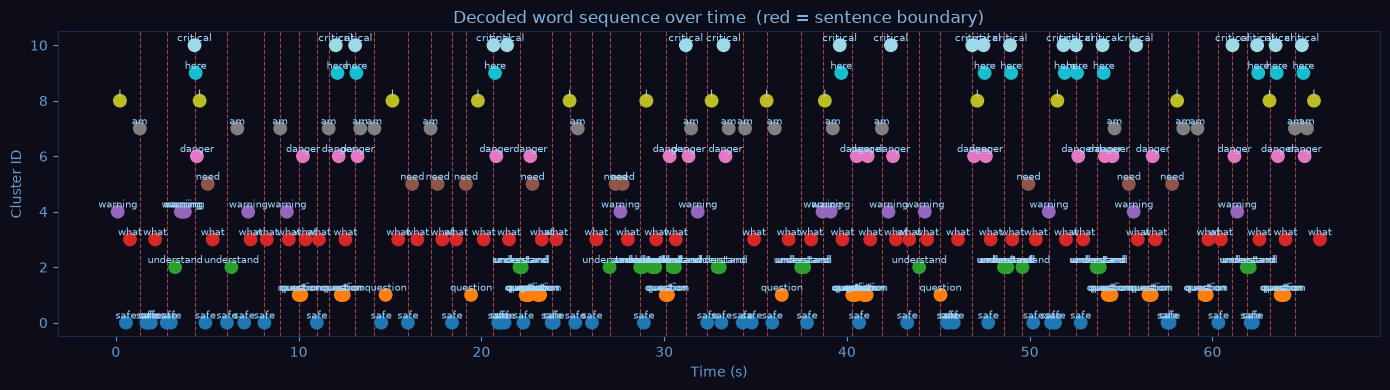

In [16]:
fig, ax = plt.subplots(figsize=(14, 4), facecolor='#0d0d1a')
ax.set_facecolor('#0d0d1a')
ax.tick_params(colors='#6699cc')
ax.xaxis.label.set_color('#6699cc')
ax.yaxis.label.set_color('#6699cc')
for s in ax.spines.values(): s.set_edgecolor('#1a2a4a')

times = [d[3] for d in decoded]
words = [d[2] for d in decoded]
clusters = [d[0] for d in decoded]

ax.scatter(times, clusters, c=clusters, cmap='tab20', s=80, zorder=3)
for t, w, c in zip(times, words, clusters):
    ax.text(t, c + 0.15, w, color='#a0d8ff', fontsize=7, ha='center')

# mark sentence boundaries
for sentence in sentences_detected[1:]:
    ax.axvline(x=sentence[0][3], color='#ff6b6b', linewidth=0.8,
               linestyle='--', alpha=0.6)

ax.set(title='Decoded word sequence over time  (red = sentence boundary)',
       xlabel='Time (s)', ylabel='Cluster ID')
ax.title.set_color('#80b4e0')
plt.tight_layout()
plt.savefig('../audio/decoded_sequence.png', dpi=150, bbox_inches='tight', facecolor='#0d0d1a')
plt.show()

## Save the completed dictionary

In [17]:
dictionary['sound_to_word']       = SOUND_TO_WORD
dictionary['decoded_sequence']    = [(c, s, w, t) for c, s, w, t in decoded]
dictionary['sentences_detected']  = [
    {
        'start_time' : s[0][3],
        'words'      : [u[2] for u in s],
        'sounds'     : [u[1] for u in s],
    }
    for s in sentences_detected
]

with open('../data/dictionary.json', 'w') as f:
    json.dump(dictionary, f, indent=2)

print('saved  data/dictionary.json  updated')
print()
print('sentences saved to dictionary:')
for i, s in enumerate(dictionary['sentences_detected']):
    print(f'  {i+1}. {" ".join(s["words"])}')


saved  data/dictionary.json  updated

sentences saved to dictionary:
  1. warning I safe what
  2. am safe safe safe what
  3. safe safe understand warning warning warning
  4. critical here danger I safe need what
  5. safe understand am safe warning what
  6. safe what
  7. am warning what
  8. question question question danger what
  9. safe what
  10. am critical here danger question question question what
  11. critical here danger am
  12. am safe question I what
  13. safe need what
  14. am need what
  15. safe what
  16. need question I what
  17. critical here danger safe safe safe critical what
  18. understand understand understand safe question question question question danger need question question question what
  19. safe safe what
  20. I safe am
  21. safe what
  22. understand need warning need what
  23. understand understand understand safe I understand understand understand what
  24. question question question danger understand understand understand what
  25. cr